In [ ]:
# wells - multiple locations
# sensors - to get the depth of well.
# multiple wells in one location
# for every location - people management
# weekly reporting -

# automate this process
# more real time answering
# c-suites -

# business need: what can be done?
# build a dashboard to show the data
# And connect the dashboard to the data and refresh it every 1 hour or 1 minute

# get data from all location, create dashboard

# You can make a RAG feed it sensors, people in and out data etc... ,
# store data as vector, in vector db.

# word vectors -
# what is the simialrity of q1 and q2, on a scale of 0 to 1, where 1 means more similar, 0 means less similar
# q1. how many people in location A
# q2. how many wells in location A

# 0.99, greater than 0.9


# sensors -> sends data -> database ->
# rig_table
# location #depth #people #volume # date #time
# A         234     320     345     20th 2.33
# A         234     320     345     20th 2.35
# ......

# what is the depth of well in location A on 20th November
# Select depth, date, location in rig_table where date='20th' and location="A"

# question -> llm [question, db schema] -> sql query -> db -> result -> llm [query, result] -> generated answer

# what is the depth of well in location A on 20th November -> LLM -> correct sql query


# can we calculate QoQ or YoY Growth and then show them on charts and dashbaord.

# do natural lang queries act as llm, I dont get that part ?
#### data ### looks like this
# natural lang queries can be converted to sql queries to answer

In [ ]:
# which player scored more goals in jan 2025
# solve this problem using langchain

# table
# member name Goal month

In [ ]:
# Langchain to solve this usecase

# 3 components
# 1. agents -> it has the reasoning capability - task done
# 2. tools -> provides information - need not have the reasoning capability
# 3. Chains -> connects multiple processes

# # question -> llm [question, db schema] -> sql query -> db -> result -> llm [query, result] -> generated answer

# step 1:
# question -> llm [question, db schema] -> sql query -> agent
# reasoning - think -> agent
# write_query - function
## step 2:
# sql query -> db -> result -> tool
#execute_query-  function
## step 3:
# result -> llm [query, result] -> generated answer -> agent
#generate_answer -function

# write_query -> execute_query -> generate_answer

In [ ]:
!pip install --upgrade --quiet langchain-community langgraph

In [4]:
import sqlite3

In [ ]:
! curl -s https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql

In [11]:
import requests, pathlib

url = "https://storage.googleapis.com/benchmarks-artifacts/chinook/Chinook.db"
local_path = pathlib.Path("Chinook.db")

if local_path.exists():
    print(f"{local_path} already exists, skipping download.")
else:
    response = requests.get(url)
    if response.status_code == 200:
        local_path.write_bytes(response.content)
        print(f"File downloaded and saved as {local_path}")
    else:
        print(f"Failed to download the file. Status code: {response.status_code}")

File downloaded and saved as Chinook.db


In [18]:
from langchain_community.utilities import SQLDatabase
db = SQLDatabase.from_uri("sqlite:///Chinook.db")


In [19]:
print(db.dialect)
print(db.get_usable_table_names())

sqlite
['Album', 'Artist', 'Customer', 'Employee', 'Genre', 'Invoice', 'InvoiceLine', 'MediaType', 'Playlist', 'PlaylistTrack', 'Track']


In [21]:
#URI
# we need to get three artists names
db.run("select name from Artist limit 10")

"[('AC/DC',), ('Accept',), ('Aerosmith',), ('Alanis Morissette',), ('Alice In Chains',), ('Antônio Carlos Jobim',), ('Apocalyptica',), ('Audioslave',), ('BackBeat',), ('Billy Cobham',)]"

In [22]:
!pip install -qU "langchain[google-genai]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.9.0 which is incompatible.


In [23]:
import getpass
import os

if not os.getenv("GOOGLE_API_KEY", None):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API KEY for Google GENAI:")

Enter API KEY for Google GENAI:··········


In [46]:
#models/gemini-2.0-flash-lite
#gemini-flash-lite-latest
from langchain.chat_models import init_chat_model
llm = init_chat_model("gemini-2.0-flash-lite",
                      model_provider="google_genai")
llm_lite = init_chat_model("gemini-flash-lite-latest",
                      model_provider="google_genai")

In [25]:
question = "how many artists are there?"
# # write_query -> execute_query -> generate_answer

# query
# generated_sql
# sql_result
# generated_answer
from typing_extensions import TypedDict
class State(TypedDict):
    query: str
    generated_sql: str
    sql_result: str
    generated_answer: str

from langchain_core.prompts import ChatPromptTemplate
system_message = """
Given an input question, create a syntactically correct {dialect} query to
run to help find the answer. Unless the user specifies in his question a
specific number of examples they wish to obtain, always limit your query to
at most {top_k} results. You can order the results by a relevant column to
return the most interesting examples in the database.

Never query for all the columns from a specific table, only ask for a the
few relevant columns given the question.

Pay attention to use only the column names that you can see in the schema
description. Be careful to not query for columns that do not exist. Also,
pay attention to which column is in which table.

Only use the following tables:
{table_info}
"""
user_prompt = "Question: {input}"
query_prompt_template = ChatPromptTemplate(
    [("system", system_message), ("user", user_prompt)]
)
for message in query_prompt_template.messages:
    message.pretty_print()

================================ System Message ================================


Given an input question, create a syntactically correct {dialect} query to
run to help find the answer. Unless the user specifies in his question a
specific number of examples they wish to obtain, always limit your query to
at most {top_k} results. You can order the results by a relevant column to
return the most interesting examples in the database.

Never query for all the columns from a specific table, only ask for a the
few relevant columns given the question.

Pay attention to use only the column names that you can see in the schema
description. Be careful to not query for columns that do not exist. Also,
pay attention to which column is in which table.

Only use the following tables:
{table_info}

================================ Human Message =================================

Question: {input}


In [26]:
from typing_extensions import Annotated
class QueryOutput(TypedDict):
    """Generated SQL query."""

    generated_sql: Annotated[str, ..., "Syntactically valid SQL query."]

def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 5,
            "table_info": db.get_table_info(),
            "input": state["query"],
        }
    )
    structured_llm = llm.with_structured_output(QueryOutput)
    print(prompt)
    result = structured_llm.invoke(prompt) #
    return {"generated_sql": result["generated_sql"]} #sql query

In [28]:
write_query({"query": "How many artists are there?"})

messages=[SystemMessage(content='\nGiven an input question, create a syntactically correct sqlite query to\nrun to help find the answer. Unless the user specifies in his question a\nspecific number of examples they wish to obtain, always limit your query to\nat most 5 results. You can order the results by a relevant column to\nreturn the most interesting examples in the database.\n\nNever query for all the columns from a specific table, only ask for a the\nfew relevant columns given the question.\n\nPay attention to use only the column names that you can see in the schema\ndescription. Be careful to not query for columns that do not exist. Also,\npay attention to which column is in which table.\n\nOnly use the following tables:\n\nCREATE TABLE "Album" (\n\t"AlbumId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(160) NOT NULL, \n\t"ArtistId" INTEGER NOT NULL, \n\tPRIMARY KEY ("AlbumId"), \n\tFOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")\n)\n\n/*\n3 rows from Album table:\nAlbumId\tT

{'generated_sql': 'SELECT COUNT(*) FROM Artist'}

In [29]:
# execute the sqlquery
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool
def execute_query(state: State):
  '''execute SQL query'''
  execute_query_tool = QuerySQLDataBaseTool(db=db)
  result = execute_query_tool.invoke(state["generated_sql"])
  return {"sql_result": result}

In [30]:
execute_query({"generated_sql": 'SELECT COUNT(*) FROM Artist'})

/tmp/ipython-input-2242718830.py:5: LangChainDeprecationWarning: The class `QuerySQLDataBaseTool` was deprecated in LangChain 0.3.12 and will be removed in 1.0. An updated version of the class exists in the `langchain-community package and should be used instead. To use it run `pip install -U `langchain-community` and import as `from `langchain_community.tools import QuerySQLDatabaseTool``.
  execute_query_tool = QuerySQLDataBaseTool(db=db)


{'sql_result': '[(275,)]'}

In [56]:
def generate_answer(state: State):
    """Answer question using retrieved information as context."""
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f"Question: {state['query']}\n"
        f"SQL Query: {state['generated_sql']}\n"
        f"SQL Result: {state['sql_result']}"
    )
    response = llm_lite.invoke(prompt)
    return {"generated_answer": response.content}

In [57]:
# agent -> graph -> nodes -> connected by edges
from langgraph.graph import START, StateGraph
graph_builder = StateGraph(State).add_sequence(
    [write_query, execute_query, generate_answer]
)

graph_builder.add_edge(START, "write_query")
graph = graph_builder.compile()

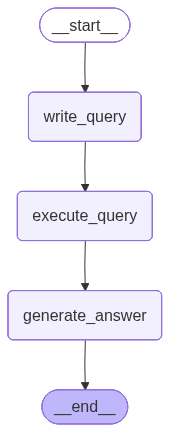

In [58]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
for step in graph.stream({"query": "How many aritists are there?"}, stream_mode="updates"):
    print(step)

messages=[SystemMessage(content='\nGiven an input question, create a syntactically correct sqlite query to\nrun to help find the answer. Unless the user specifies in his question a\nspecific number of examples they wish to obtain, always limit your query to\nat most 5 results. You can order the results by a relevant column to\nreturn the most interesting examples in the database.\n\nNever query for all the columns from a specific table, only ask for a the\nfew relevant columns given the question.\n\nPay attention to use only the column names that you can see in the schema\ndescription. Be careful to not query for columns that do not exist. Also,\npay attention to which column is in which table.\n\nOnly use the following tables:\n\nCREATE TABLE "Album" (\n\t"AlbumId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(160) NOT NULL, \n\t"ArtistId" INTEGER NOT NULL, \n\tPRIMARY KEY ("AlbumId"), \n\tFOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")\n)\n\n/*\n3 rows from Album table:\nAlbumId\tT

In [44]:
for step in graph.stream({"query": "Which country's customers spent the most?"}, stream_mode="updates"):
    print(step)
# LCEL and Langraph diff

messages=[SystemMessage(content='\nGiven an input question, create a syntactically correct sqlite query to\nrun to help find the answer. Unless the user specifies in his question a\nspecific number of examples they wish to obtain, always limit your query to\nat most 5 results. You can order the results by a relevant column to\nreturn the most interesting examples in the database.\n\nNever query for all the columns from a specific table, only ask for a the\nfew relevant columns given the question.\n\nPay attention to use only the column names that you can see in the schema\ndescription. Be careful to not query for columns that do not exist. Also,\npay attention to which column is in which table.\n\nOnly use the following tables:\n\nCREATE TABLE "Album" (\n\t"AlbumId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(160) NOT NULL, \n\t"ArtistId" INTEGER NOT NULL, \n\tPRIMARY KEY ("AlbumId"), \n\tFOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")\n)\n\n/*\n3 rows from Album table:\nAlbumId\tT

In [45]:
for step in graph.stream({"query": "all albums by an artist ac/dc"}, stream_mode="updates"):
    print(step)

messages=[SystemMessage(content='\nGiven an input question, create a syntactically correct sqlite query to\nrun to help find the answer. Unless the user specifies in his question a\nspecific number of examples they wish to obtain, always limit your query to\nat most 5 results. You can order the results by a relevant column to\nreturn the most interesting examples in the database.\n\nNever query for all the columns from a specific table, only ask for a the\nfew relevant columns given the question.\n\nPay attention to use only the column names that you can see in the schema\ndescription. Be careful to not query for columns that do not exist. Also,\npay attention to which column is in which table.\n\nOnly use the following tables:\n\nCREATE TABLE "Album" (\n\t"AlbumId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(160) NOT NULL, \n\t"ArtistId" INTEGER NOT NULL, \n\tPRIMARY KEY ("AlbumId"), \n\tFOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")\n)\n\n/*\n3 rows from Album table:\nAlbumId\tT

In [59]:
for step in graph.stream({"query": "difference in amount spent by US and other country"}, stream_mode="updates"):
    print(step)

messages=[SystemMessage(content='\nGiven an input question, create a syntactically correct sqlite query to\nrun to help find the answer. Unless the user specifies in his question a\nspecific number of examples they wish to obtain, always limit your query to\nat most 5 results. You can order the results by a relevant column to\nreturn the most interesting examples in the database.\n\nNever query for all the columns from a specific table, only ask for a the\nfew relevant columns given the question.\n\nPay attention to use only the column names that you can see in the schema\ndescription. Be careful to not query for columns that do not exist. Also,\npay attention to which column is in which table.\n\nOnly use the following tables:\n\nCREATE TABLE "Album" (\n\t"AlbumId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(160) NOT NULL, \n\t"ArtistId" INTEGER NOT NULL, \n\tPRIMARY KEY ("AlbumId"), \n\tFOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")\n)\n\n/*\n3 rows from Album table:\nAlbumId\tT

In [60]:
out = graph.invoke({"query": "average unit price of tracks by an artist ac/dc along with genre"})
out['generated_answer']

messages=[SystemMessage(content='\nGiven an input question, create a syntactically correct sqlite query to\nrun to help find the answer. Unless the user specifies in his question a\nspecific number of examples they wish to obtain, always limit your query to\nat most 5 results. You can order the results by a relevant column to\nreturn the most interesting examples in the database.\n\nNever query for all the columns from a specific table, only ask for a the\nfew relevant columns given the question.\n\nPay attention to use only the column names that you can see in the schema\ndescription. Be careful to not query for columns that do not exist. Also,\npay attention to which column is in which table.\n\nOnly use the following tables:\n\nCREATE TABLE "Album" (\n\t"AlbumId" INTEGER NOT NULL, \n\t"Title" NVARCHAR(160) NOT NULL, \n\t"ArtistId" INTEGER NOT NULL, \n\tPRIMARY KEY ("AlbumId"), \n\tFOREIGN KEY("ArtistId") REFERENCES "Artist" ("ArtistId")\n)\n\n/*\n3 rows from Album table:\nAlbumId\tT

"The average unit price of tracks by the artist 'ac/dc' for the 'Rock' genre is **0.99**."